# Hyperparameter sweep

Goal:

- Train one model per hyperparameter combination.
- Track every run in the SageMaker MLflow tracking server.
- Export the best model to `s3://<bucket>/notebook/models/`.

Grid search tests every combination in a predefined matrix, so each run differs
in exactly one way and the comparison is fair.


## Environment

Install libraries.


In [1]:
# psutil backs MLflow's system metrics; pynvml adds the GPU rows on top
%pip install -q -U ultralytics torch torchvision onnx onnxruntime onnxslim mlflow sagemaker-mlflow psutil pynvml

Note: you may need to restart the kernel to use updated packages.


Inspect environment.


In [2]:
%matplotlib inline

import os
import sys
from pathlib import Path

import boto3
import matplotlib.pyplot as plt
import mlflow
import pandas as pd
import torch

from sagemaker.core.helper.session_helper import Session

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

from notebook.code.tracking import tracking_status, tracking_uri

# local dir
RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"
RUNS = ROOT / "runs"
MODELS = ROOT / "models"

# create dir
for d in (RAW, PROCESSED, RUNS, MODELS):
    d.mkdir(parents=True, exist_ok=True)

REGION = Session().boto_region_name

# get s3 bucket
env_file = Path.home() / ".sagemaker-yolo.env"
if "BUCKET" not in os.environ and env_file.exists():
    for line in env_file.read_text().splitlines():
        key, _, val = line.partition("=")
        os.environ.setdefault(key.strip(), val.strip())

BUCKET = os.environ["BUCKET"]

# bucket keys
S3_RAW = f"s3://{BUCKET}/raw-data/"
S3_SPLIT = f"s3://{BUCKET}/notebook/split-data"
S3_MODELS = f"s3://{BUCKET}/notebook/models"

# get device
DEVICE = 0 if torch.cuda.is_available() else "cpu"
# device tag
device_tag = "gpu" if torch.cuda.is_available() else "cpu"

# set tracking server
TRACKING_URI = tracking_uri()
mlflow.set_tracking_uri(TRACKING_URI)

# sample CPU/GPU/memory/disk/network into every run from here on.
# off by default, and silently a no-op if psutil is not installed
mlflow.enable_system_metrics_logging()
# default is one sample every 10s logged individually, which leaves a short run
# with almost no points; sample faster and average to keep the charts readable
mlflow.set_system_metrics_sampling_interval(5)
mlflow.set_system_metrics_samples_before_logging(2)

# define experiment
EXPERIMENT = "yolo-plate-detection-sweep"
experiment = mlflow.set_experiment(EXPERIMENT)

# get tracking backend UI url (presigned and expiring for the app)
UI_URL = tracking_status(TRACKING_URI)["ui_url"]

# print environment
print("torch     ", torch.__version__)
print("cuda      ", torch.cuda.is_available())
print("device    ", device_tag)
print("bucket    ", BUCKET)
print("tracking  ", TRACKING_URI)
print("experiment", EXPERIMENT, f"(id {experiment.experiment_id})")
print(f"\nUI: {UI_URL}/#/experiments/{experiment.experiment_id}")

/opt/conda/lib/python3.12/site-packages/torch/cuda/__init__.py:64: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


torch      2.13.0+cu130
cuda       True
device     gpu
bucket     sagemaker-yolo-dev-up68ac
tracking   arn:aws:sagemaker:ca-central-1:099139718958:mlflow-app/app-XWJPU4F3CZ44
experiment yolo-plate-detection-sweep (id 2)

UI: https://app-XWJPU4F3CZ44.mlflow.sagemaker.ca-central-1.app.aws/auth?authToken=eyJhbGciOiJIUzI1NiJ9.eyJhdXRoVG9rZW5JZCI6Ik5NUjZGUSIsImZhc0NyZWRlbnRpYWxzIjoiQWdWNDhSckU3OExad3VqK3N6ejhNQmVCWGk5dWpkaml0TllVbUxOcGxHcnZGKzhBWHdBQkFCVmhkM010WTNKNWNIUnZMWEIxWW14cFl5MXJaWGtBUkVFMFlucFRWRVJNTVVZMFlYRnZNMUpzY1ZKc2RISlFjbGN4T1haaVFYTlhjelJRS3pkNldtWllhbGsxY1RKWE1HbzBXSEJFVlZscVMySTNSVzl4YTB4SVFUMDlBQUVBQjJGM2N5MXJiWE1BVG1GeWJqcGhkM002YTIxek9tTmhMV05sYm5SeVlXd3RNVG95TnpjM01EY3hNek0yTlRrNmEyVjVMMlkzT1RNek5HSTBMVEptWVRZdE5EQTFNaTFoTXpVNUxUWmtOMkU0TWpNd09XUXlZZ0M0QVFJQkFIakliOVNXSGk1RXhqMmRBNndCc2hQbWxNWjluNUxYSW1KODJnRWREbVMvbEFFL2NzSHVsbVovRTlsSEFtaXAvSkQ0QUFBQWZqQjhCZ2txaGtpRzl3MEJCd2FnYnpCdEFnRUFNR2dHQ1NxR1NJYjNEUUVIQVRBZUJnbGdoa2dCWlFNRUFTNHdFUVFNTzRSU2w1ek94RUR0YlZSd0FnRVFn

## Split data

Download raw data, split, and store in bucket.


In [3]:
from notebook.code.data_loader import build_split, verify_split, write_data_yaml
from notebook.code.s3_sync import download, upload

# e.g. 100 for a fast smoke run
# LIMIT = 10
LIMIT = None  # all images

SPLIT_SEED = 0 # split random seed

# download
print(download(S3_RAW, RAW))

# split
print(build_split(RAW, PROCESSED, val_fraction=0.2, limit=LIMIT, seed=SPLIT_SEED))
print(verify_split(PROCESSED))

# store split
print(upload(PROCESSED, S3_SPLIT, delete=True))

# create data config yaml file
names = (RAW / "classes.txt").read_text().split()
data_yaml = write_data_yaml(ROOT / "configs" / "data.yaml", PROCESSED, names)
print(data_yaml.read_text())

{'downloaded': 0, 'skipped': 1113}


{'train': 445, 'val': 111, 'orphan_images': 0, 'orphan_labels': 0}
{'train': 445, 'val': 111}


{'uploaded': 0, 'skipped': 1112, 'removed': 0}
path: /home/sagemaker-user/sagemaker-yolo/data/processed
train: train/images
val: val/images
nc: 1
names: ['car_plate']



## Define sweep

Define combination of training hyperparameters(`GRID`).


In [4]:
from itertools import product

from notebook.code.data_loader import build_train_cfg

# create training hyperparameters
base_cfg = build_train_cfg(
    device=DEVICE,
    workers=(os.cpu_count() or 2) if DEVICE != "cpu" else 0,
)
base_cfg["project"] = str(ROOT / base_cfg["project"])

# count images
n_images = sum(len(list((PROCESSED / s / "images").iterdir())) for s in ("train", "val"))
tag = "gpu" if DEVICE != "cpu" else "cpu"

# the axes to sweep; add keys here to widen the grid
SWEEP = {
    "epochs": (10, 20, 30, 40, 50),
}

# define grid
GRID = []
for values in product(*SWEEP.values()):
    overrides = dict(zip(SWEEP.keys(), values))
    suffix = "-".join(f"{k}{v}" for k, v in overrides.items())
    overrides["name"] = f"tune-{tag}-{n_images}img-{base_cfg['imgsz']}px-{suffix}"
    GRID.append(overrides)

# print grid
print(f"experiment {EXPERIMENT}")
print(f"{len(GRID)} runs")
for g in GRID:
    print(" ", g)

experiment yolo-plate-detection-sweep
5 runs
  {'epochs': 10, 'name': 'tune-gpu-556img-640px-epochs10'}
  {'epochs': 20, 'name': 'tune-gpu-556img-640px-epochs20'}
  {'epochs': 30, 'name': 'tune-gpu-556img-640px-epochs30'}
  {'epochs': 40, 'name': 'tune-gpu-556img-640px-epochs40'}
  {'epochs': 50, 'name': 'tune-gpu-556img-640px-epochs50'}


## Run sweep

Loop each grid entry on its own MLflow run.


In [5]:
from notebook.code.tracking import run_sweep

results = run_sweep(
    grid=GRID,
    base_cfg=base_cfg,
    data_yaml=data_yaml,
    processed_dir=PROCESSED,
    raw_dir=RAW,
    experiment=EXPERIMENT,
    # keep the mlflow run name and the run directory the same
    run_name=lambda cfg: cfg["name"],
)

summary = pd.DataFrame(results)
summary


[1/5] tune-gpu-556img-640px-epochs10  {'epochs': 10, 'name': 'tune-gpu-556img-640px-epochs10'}


Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.13.0+cu130 CUDA:0 (Tesla T4, 14913MiB)


engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/sagemaker-user/sagemaker-yolo/configs/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=tune-gpu-556img-640px-epochs10, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto

Overriding model.yaml nc=80 with nc=1



                   from  n    params  module                                       arguments                     


...

2026/08/15 04:13:02 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...


🏃 View run tune-gpu-556img-640px-epochs50 at: https://mlflow.sagemaker.ca-central-1.app.aws/#/experiments/2/runs/29e817e747cb438081f4b0122ed70c2f
🧪 View experiment at: https://mlflow.sagemaker.ca-central-1.app.aws/#/experiments/2


2026/08/15 04:13:02 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


[5/5] done in 517s


,name,run_id,save_dir,epochs,mAP50,mAP50-95,elapsed_s
0,tune-gpu-556img-640px-epochs10,3a96c6c8ceea4fb2be9c9d1ff2927a44,/home/sagemaker-user/sagemaker-yolo/runs/tune-...,10,0.937607,0.762496,131
1,tune-gpu-556img-640px-epochs20,c97434c1478a4c9fa9144dde35f8c956,/home/sagemaker-user/sagemaker-yolo/runs/tune-...,20,0.977499,0.812849,211
2,tune-gpu-556img-640px-epochs30,ce0c336f52c74fe19d94da0973ee51a1,/home/sagemaker-user/sagemaker-yolo/runs/tune-...,30,0.980724,0.830816,311
3,tune-gpu-556img-640px-epochs40,30c3dadd7c9a46e09986a3ad3139327e,/home/sagemaker-user/sagemaker-yolo/runs/tune-...,40,0.977551,0.820559,413
4,tune-gpu-556img-640px-epochs50,29e817e747cb438081f4b0122ed70c2f,/home/sagemaker-user/sagemaker-yolo/runs/tune-...,50,0.974761,0.833605,517


## Compare runs

Every run in the experiment, side by side.


In [6]:
from notebook.code.tracking import compare_runs

compare_runs(EXPERIMENT)

,mlflow.runName,epochs,imgsz,data.train_images,metrics/mAP50B,metrics/mAP50-95B,metrics/precisionB,metrics/recallB
0,tune-gpu-556img-640px-epochs50,50,640,445,0.974761,0.833605,0.943757,0.939655
1,tune-gpu-556img-640px-epochs40,40,640,445,0.977551,0.820559,0.968625,0.922414
2,tune-gpu-556img-640px-epochs30,30,640,445,0.980724,0.830816,0.982138,0.948007
3,tune-gpu-556img-640px-epochs20,20,640,445,0.977499,0.812849,0.994355,0.905172
4,tune-gpu-556img-640px-epochs10,10,640,445,0.937607,0.762496,0.854101,0.879310
5,tune-gpu-556img-640px-epochs50,50,640,445,0.974761,0.833605,0.943757,0.939655
6,tune-gpu-556img-640px-epochs40,40,640,445,0.977551,0.820559,0.968625,0.922414
7,tune-gpu-556img-640px-epochs30,30,640,445,0.980724,0.830816,0.982138,0.948007
8,tune-gpu-556img-640px-epochs20,20,640,445,0.977499,0.812849,0.994355,0.905172
9,tune-gpu-556img-640px-epochs10,10,640,445,0.937607,0.762496,0.854101,0.879310


Plot sweep runs.


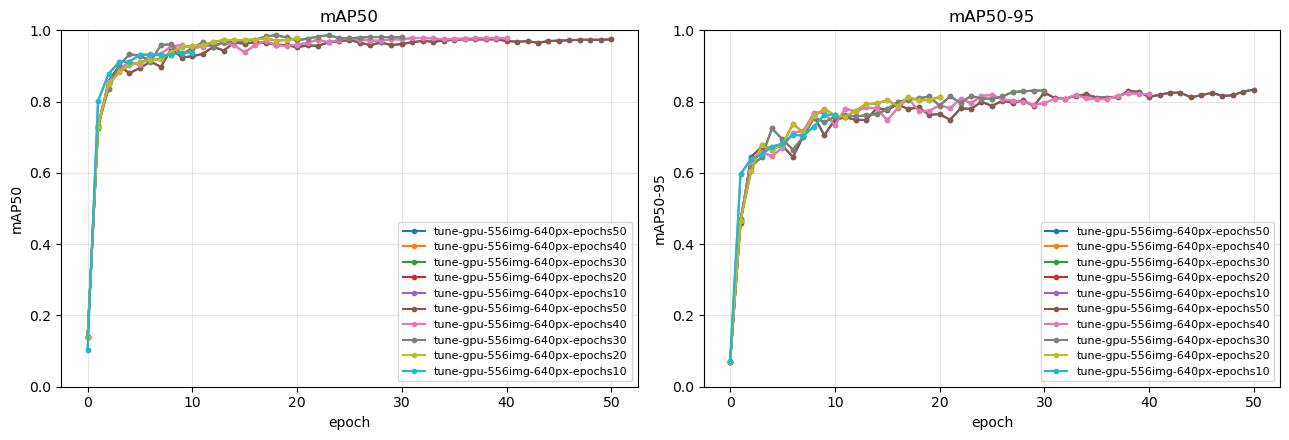

In [7]:
client = mlflow.tracking.MlflowClient()
runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id])

# only this sweep's runs; the experiment accumulates older ones
wanted = [g["name"] for g in GRID]
runs = runs[runs["params.name"].isin(wanted)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for _, row in runs.iterrows():
    for ax, metric in zip(axes, ("metrics/mAP50B", "metrics/mAP50-95B")):
        # mlflow does not guarantee ordering, sort by step before plotting
        history = sorted(client.get_metric_history(row["run_id"], metric), key=lambda p: p.step)
        if history:
            ax.plot(
                [p.step for p in history],
                [p.value for p in history],
                marker="o", ms=3, label=row["tags.mlflow.runName"],
            )

for ax, metric in zip(axes, ("mAP50", "mAP50-95")):
    ax.set_xlabel("epoch")
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Metrics vs Time: Cost against benefit

More epochs almost always helps a little: **whether the gain justifies the minutes**.

- `gain` and `extra_min` are measured against the cheapest run in the sweep.


In [8]:
cols = {
    "tags.mlflow.runName": "run",
    "params.epochs": "epochs",
    "metrics.metrics/mAP50-95B": "mAP50-95",
    "metrics.elapsed_seconds": "seconds",
}
cost = runs[[c for c in cols if c in runs.columns]].rename(columns=cols)
cost = cost.dropna(subset=["seconds"]).sort_values("seconds")

# baseline is the cheapest run
base = cost.iloc[0]
cost["minutes"] = (cost["seconds"] / 60).round(1)
cost["gain"] = (cost["mAP50-95"] - base["mAP50-95"]).round(4)
cost["extra_min"] = ((cost["seconds"] - base["seconds"]) / 60).round(1)

# minutes spent per 0.01 mAP gained; NaN for the baseline itself
cost["min_per_0.01"] = (cost["extra_min"] / (cost["gain"] * 100)).round(1)

cost[["run", "epochs", "mAP50-95", "minutes", "gain", "extra_min", "min_per_0.01"]]

,run,epochs,mAP50-95,minutes,gain,extra_min,min_per_0.01
4,tune-gpu-556img-640px-epochs10,10,0.762496,2.2,0.0000,0.0,NaN
9,tune-gpu-556img-640px-epochs10,10,0.762496,2.3,0.0000,0.2,inf
3,tune-gpu-556img-640px-epochs20,20,0.812849,3.5,0.0504,1.3,0.3
8,tune-gpu-556img-640px-epochs20,20,0.812849,4.4,0.0504,2.2,0.4
7,tune-gpu-556img-640px-epochs30,30,0.830816,5.1,0.0683,3.0,0.4
2,tune-gpu-556img-640px-epochs30,30,0.830816,5.2,0.0683,3.0,0.4
6,tune-gpu-556img-640px-epochs40,40,0.820559,6.8,0.0581,4.6,0.8
1,tune-gpu-556img-640px-epochs40,40,0.820559,6.9,0.0581,4.7,0.8
5,tune-gpu-556img-640px-epochs50,50,0.833605,8.4,0.0711,6.2,0.9
0,tune-gpu-556img-640px-epochs50,50,0.833605,8.6,0.0711,6.4,0.9


## Export the best model

Pick the run with the highest mAP50-95, then export its weights.


In [9]:
# filter metric
METRIC = "mAP50-95"

# filter completed runs
finished = [r for r in results if "error" not in r]
if not finished:
    # error if all fail.
    raise RuntimeError("every run in the sweep failed")

# sort
ranked = sorted(finished, key=lambda r: r[METRIC], reverse=True)
# get best
best_run = ranked[0]

# print best
print(f"compared {len(finished)} of {len(GRID)} runs\n")
for r in ranked:
    print(f"  {r[METRIC]:.4f}  {r['elapsed_s']:>6}s  {r['name']}")

print(f"\nbest      {best_run['name']}")
print(f"mAP50-95  {best_run[METRIC]:.4f}")
print(f"run_id    {best_run['run_id']}")

compared 5 of 5 runs

  0.8336     517s  tune-gpu-556img-640px-epochs50
  0.8308     311s  tune-gpu-556img-640px-epochs30
  0.8206     413s  tune-gpu-556img-640px-epochs40
  0.8128     211s  tune-gpu-556img-640px-epochs20
  0.7625     131s  tune-gpu-556img-640px-epochs10

best      tune-gpu-556img-640px-epochs50
mAP50-95  0.8336
run_id    29e817e747cb438081f4b0122ed70c2f


Export model.


In [10]:
import shutil

from ultralytics import YOLO

# get best save dir
save_dir = Path(best_run["save_dir"])
# construct best model
best = YOLO(str(save_dir / "weights" / "best.pt"))

# imgsz must match training
imgsz = base_cfg["imgsz"]
exported = Path(best.export(format="onnx", imgsz=imgsz, opset=12, simplify=True))

onnx_path = MODELS / f"{best_run['name']}.onnx"
shutil.move(str(exported), onnx_path)

print(onnx_path.name)
print(f"{onnx_path.stat().st_size / 1e6:.1f} MB")

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.13.0+cu130 CPU (Intel Xeon Platinum 8259CL CPU @ 2.50GHz)


YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.3 GFLOPs



PyTorch: starting from '/home/sagemaker-user/sagemaker-yolo/runs/tune-gpu-556img-640px-epochs50/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.1 MB)



ONNX: starting export with onnx 1.22.0 opset 12...


ONNX: slimming with onnxslim 0.1.95...


2026-08-15 04:13:06.376589076 [W:onnxruntime:Default, device_discovery.cc:285 GetGpuDevices] Failed to detect devices under "/sys/class/drm/card0": device_discovery.cc:94 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"


ONNX: export success ✅ 1.5s, saved as '/home/sagemaker-user/sagemaker-yolo/runs/tune-gpu-556img-640px-epochs50/weights/best.onnx' (9.4 MB)



Export complete (1.9s)
Results saved to /home/sagemaker-user/sagemaker-yolo/runs/tune-gpu-556img-640px-epochs50/weights/best.onnx
Predict:         yolo predict task=detect model=/home/sagemaker-user/sagemaker-yolo/runs/tune-gpu-556img-640px-epochs50/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/home/sagemaker-user/sagemaker-yolo/runs/tune-gpu-556img-640px-epochs50/weights/best.onnx imgsz=640 data=/home/sagemaker-user/sagemaker-yolo/configs/data.yaml  
Visualize:       https://netron.app


tune-gpu-556img-640px-epochs50.onnx
9.8 MB


Export metadata file.


In [11]:
import json
from datetime import datetime, timezone

# the graph carries neither class names nor imgsz; the predictor needs both
sidecar = onnx_path.with_suffix(".metadata.json")
sidecar.write_text(json.dumps({
    "imgsz": imgsz,
    "names": [best.names[i] for i in sorted(best.names)],
    "metrics": {
        "mAP50": round(best_run["mAP50"], 4),
        "mAP50-95": round(best_run["mAP50-95"], 4),
    },
    "mlflow": {
        "run_id": best_run["run_id"],
        "experiment": EXPERIMENT,
        "tracking_uri": TRACKING_URI,
    },
    "sweep": {
        "axes": {k: list(v) for k, v in SWEEP.items()},
        "won_with": {k: best_run[k] for k in SWEEP},
        "runs_compared": len(finished),
    },
    "images": n_images,
    "exported_at": datetime.now(timezone.utc).isoformat(),
}, indent=2))

print(sidecar.read_text())

{
  "imgsz": 640,
  "names": [
    "car_plate"
  ],
  "metrics": {
    "mAP50": 0.9748,
    "mAP50-95": 0.8336
  },
  "mlflow": {
    "run_id": "29e817e747cb438081f4b0122ed70c2f",
    "experiment": "yolo-plate-detection-sweep",
    "tracking_uri": "arn:aws:sagemaker:ca-central-1:099139718958:mlflow-app/app-XWJPU4F3CZ44"
  },
  "sweep": {
    "axes": {
      "epochs": [
        10,
        20,
        30,
        40,
        50
      ]
    },
    "won_with": {
      "epochs": 50
    },
    "runs_compared": 5
  },
  "images": 556,
  "exported_at": "2026-08-15T04:13:07.022930+00:00"
}


### Export hyperparameters for the train pipeline

Freeze the winning configuration to `train/hyperparams.json`, then **commit it**.

The pipeline reads that file and never queries MLflow, so once it is committed
the tracking server can be shut down and training still reproduces this run.
Committing the file is also what triggers the automated train job.


In [12]:
from notebook.code.tracking import export_hyperparams

hyperparams_path = export_hyperparams(
    ROOT / "train" / "hyperparams.json",
    best_run=best_run,
    base_cfg=base_cfg,
    sweep_axes=SWEEP,
    experiment=EXPERIMENT,
    tracking_uri=TRACKING_URI,
    metric=METRIC,
    n_compared=len(finished),
)

# review, then: git add train/hyperparams.json && git commit && git push
print(hyperparams_path)
print(hyperparams_path.read_text())


/home/sagemaker-user/sagemaker-yolo/train/hyperparams.json
{
  "schema": 1,
  "hyperparameters": {
    "epochs": 50,
    "imgsz": 640,
    "batch": 8,
    "seed": 0
  },
  "provenance": {
    "run_id": "29e817e747cb438081f4b0122ed70c2f",
    "experiment": "yolo-plate-detection-sweep",
    "tracking_uri": "arn:aws:sagemaker:ca-central-1:099139718958:mlflow-app/app-XWJPU4F3CZ44",
    "metric": "mAP50-95",
    "value": 0.8336,
    "swept_axes": {
      "epochs": [
        10,
        20,
        30,
        40,
        50
      ]
    },
    "runs_compared": 5,
    "exported_at": "2026-08-15T04:13:07.029279+00:00"
  }
}



Bundle the winner into `model.tar.gz`, upload it to S3, and attach the export to its MLflow run.


In [13]:
import tarfile

from notebook.code.s3_sync import list_objects, upload_files

bundle = MODELS / "model.tar.gz"
members = [onnx_path, sidecar, save_dir / "weights" / "best.pt"]

# flat archive.
with tarfile.open(bundle, "w:gz") as tar:
    for path in members:
        tar.add(path, arcname=path.name)

raw_bytes = sum(p.stat().st_size for p in members)
print(bundle.name)
print(f"{raw_bytes / 1e6:.1f} MB  ->  {bundle.stat().st_size / 1e6:.1f} MB")
with tarfile.open(bundle) as tar:
    for name in tar.getnames():
        print(f"  {name}")

# one prefix per model, since every bundle is named model.tar.gz by convention
dest = f"{S3_MODELS}/{best_run['name']}"

print()
# upload the deployable bundle
for uri in upload_files([bundle], dest):
    print(uri)

model_data_url = f"{dest}/{bundle.name}"
print(f"\nModelDataUrl  {model_data_url}")

# confirm
with mlflow.start_run(run_id=best_run["run_id"]):
    mlflow.log_artifact(str(onnx_path), artifact_path="export")
    mlflow.log_artifact(str(sidecar), artifact_path="export")
    mlflow.set_tag("export.s3_uri", dest)
    mlflow.set_tag("export.model_data_url", model_data_url)
    mlflow.set_tag("sweep.winner", "true")

print()
for key, meta in sorted(list_objects(dest).items()):
    print(f"  {meta['size'] / 1e6:>6.1f} MB  {key.rsplit('/', 1)[-1]}")

print(f"\nrun: {UI_URL}/#/experiments/{experiment.experiment_id}/runs/{best_run['run_id']}")

model.tar.gz
15.2 MB  ->  13.3 MB
  tune-gpu-556img-640px-epochs50.onnx
  tune-gpu-556img-640px-epochs50.metadata.json
  best.pt



s3://sagemaker-yolo-dev-up68ac/notebook/models/tune-gpu-556img-640px-epochs50/model.tar.gz

ModelDataUrl  s3://sagemaker-yolo-dev-up68ac/notebook/models/tune-gpu-556img-640px-epochs50/model.tar.gz


2026/08/15 04:13:08 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.


2026/08/15 04:13:09 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...


2026/08/15 04:13:09 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


🏃 View run tune-gpu-556img-640px-epochs50 at: https://mlflow.sagemaker.ca-central-1.app.aws/#/experiments/2/runs/29e817e747cb438081f4b0122ed70c2f
🧪 View experiment at: https://mlflow.sagemaker.ca-central-1.app.aws/#/experiments/2



    13.3 MB  model.tar.gz

run: https://app-XWJPU4F3CZ44.mlflow.sagemaker.ca-central-1.app.aws/auth?authToken=eyJhbGciOiJIUzI1NiJ9.eyJhdXRoVG9rZW5JZCI6Ik5NUjZGUSIsImZhc0NyZWRlbnRpYWxzIjoiQWdWNDhSckU3OExad3VqK3N6ejhNQmVCWGk5dWpkaml0TllVbUxOcGxHcnZGKzhBWHdBQkFCVmhkM010WTNKNWNIUnZMWEIxWW14cFl5MXJaWGtBUkVFMFlucFRWRVJNTVVZMFlYRnZNMUpzY1ZKc2RISlFjbGN4T1haaVFYTlhjelJRS3pkNldtWllhbGsxY1RKWE1HbzBXSEJFVlZscVMySTNSVzl4YTB4SVFUMDlBQUVBQjJGM2N5MXJiWE1BVG1GeWJqcGhkM002YTIxek9tTmhMV05sYm5SeVlXd3RNVG95TnpjM01EY3hNek0yTlRrNmEyVjVMMlkzT1RNek5HSTBMVEptWVRZdE5EQTFNaTFoTXpVNUxUWmtOMkU0TWpNd09XUXlZZ0M0QVFJQkFIakliOVNXSGk1RXhqMmRBNndCc2hQbWxNWjluNUxYSW1KODJnRWREbVMvbEFFL2NzSHVsbVovRTlsSEFtaXAvSkQ0QUFBQWZqQjhCZ2txaGtpRzl3MEJCd2FnYnpCdEFnRUFNR2dHQ1NxR1NJYjNEUUVIQVRBZUJnbGdoa2dCWlFNRUFTNHdFUVFNTzRSU2w1ek94RUR0YlZSd0FnRVFnRHVjSGRvT0hnSmN6Z2x1M2xPZ2N0UjNBNXJVeEcvLzZsNkJYVFU3NzZHTHhuRm9pWGdvOGVUc2ZFZzBNTjdSY0xGT2tSdURIRW5BY3V3Z3V3SUFBQkFBTDAvZElud0VHaFUvQ08wTjR2cE81ODBaQjZFKzFEaGVTZnJmVnJLWWhHYm83N0tIZUpxSkp4cloxd

## Gate and register the winner

- Same gates as the single-run notebook, applied to the sweep winner.
- Promotion is decided inside `register_model`, so both notebooks compete for one `champion` alias under one rule.


In [ ]:
from notebook.code.tracking import MIN_MAP, PROMOTION_MARGIN, check_export_parity, register_model

REGISTERED_MODEL = "sagemaker-yolo-sweep"

# score the exported onnx against the winning run's .pt metric
parity = check_export_parity(
    onnx_path, data_yaml, reference_map=best_run[METRIC], imgsz=imgsz
)
print(f"parity  onnx {parity['onnx_map']:.4f}  pt {parity['reference_map']:.4f}  "
      f"delta {parity['delta']:.4f}  {'ok' if parity['passed'] else 'FAILED'}")

outcome = register_model(
    best_run["run_id"],
    onnx_path,
    REGISTERED_MODEL,
    min_map=MIN_MAP,
    margin=PROMOTION_MARGIN,
    parity=parity,
)

print(f"\nwinner     {best_run['name']}")
print(f"score      {outcome['score']:.4f}  (floor {MIN_MAP})")
if not outcome["registered"]:
    print(f"REJECTED   {outcome['reason']}")
else:
    print(f"registered version {outcome['version']}")
    if outcome["promoted"]:
        print(f"champion   -> version {outcome['version']}")
    else:
        print(f"champion   stays at version {outcome['champion_version']} "
              f"({outcome['champion_score']:.4f})")
    print(f"\nmodel: {UI_URL}/#/models/{REGISTERED_MODEL}/versions/{outcome['version']}")


WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify', 'pose', 'obb' or 'semantic'.


Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.13.0+cu130 CUDA:0 (Tesla T4, 14913MiB)


Loading /home/sagemaker-user/sagemaker-yolo/models/tune-gpu-556img-640px-epochs50.onnx for ONNX Runtime inference...


WARNING ⚠️ CUDA requested but CUDAExecutionProvider not available. Using CPU...


Using ONNX Runtime 1.28.0 with CPUExecutionProvider


...

Created version '4' of model 'yolo-plate-detection'.


2026/08/15 04:13:38 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...


2026/08/15 04:13:38 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


🏃 View run tune-gpu-556img-640px-epochs50 at: https://mlflow.sagemaker.ca-central-1.app.aws/#/experiments/2/runs/29e817e747cb438081f4b0122ed70c2f
🧪 View experiment at: https://mlflow.sagemaker.ca-central-1.app.aws/#/experiments/2



winner     tune-gpu-556img-640px-epochs50
score      0.8336  (floor 0.7)
registered version 4
champion   stays at version 2 (0.8336)

model: https://app-XWJPU4F3CZ44.mlflow.sagemaker.ca-central-1.app.aws/auth?authToken=eyJhbGciOiJIUzI1NiJ9.eyJhdXRoVG9rZW5JZCI6Ik5NUjZGUSIsImZhc0NyZWRlbnRpYWxzIjoiQWdWNDhSckU3OExad3VqK3N6ejhNQmVCWGk5dWpkaml0TllVbUxOcGxHcnZGKzhBWHdBQkFCVmhkM010WTNKNWNIUnZMWEIxWW14cFl5MXJaWGtBUkVFMFlucFRWRVJNTVVZMFlYRnZNMUpzY1ZKc2RISlFjbGN4T1haaVFYTlhjelJRS3pkNldtWllhbGsxY1RKWE1HbzBXSEJFVlZscVMySTNSVzl4YTB4SVFUMDlBQUVBQjJGM2N5MXJiWE1BVG1GeWJqcGhkM002YTIxek9tTmhMV05sYm5SeVlXd3RNVG95TnpjM01EY3hNek0yTlRrNmEyVjVMMlkzT1RNek5HSTBMVEptWVRZdE5EQTFNaTFoTXpVNUxUWmtOMkU0TWpNd09XUXlZZ0M0QVFJQkFIakliOVNXSGk1RXhqMmRBNndCc2hQbWxNWjluNUxYSW1KODJnRWREbVMvbEFFL2NzSHVsbVovRTlsSEFtaXAvSkQ0QUFBQWZqQjhCZ2txaGtpRzl3MEJCd2FnYnpCdEFnRUFNR2dHQ1NxR1NJYjNEUUVIQVRBZUJnbGdoa2dCWlFNRUFTNHdFUVFNTzRSU2w1ek94RUR0YlZSd0FnRVFnRHVjSGRvT0hnSmN6Z2x1M2xPZ2N0UjNBNXJVeEcvLzZsNkJYVFU3NzZHTHhuRm9pWGdvOGVUc2ZFZzBNTjd